In [1]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from sklearn.datasets import load_digits

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The path for HAFS consolidated Date
folder_path = 'Model_Data/CompleteData'

# HAFS Data is in multiple NC files. Consolidate_Data creates one dataset
ds = utils.consolidate_data(folder_path)

# Checking for NA's
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')

# Limiting frames to tropical storm strength or stronger (17 m/s or stronger)
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] >= 17, drop = True)

# Only using storms in the Northern Hemisphere
ds_cleaned = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)

: 

In [3]:
ds_cleaned

<xarray.Dataset> Size: 9GB
Dimensions:          (frame_number: 429, levels: 3, angle: 720, radius: 501)
Coordinates:
  * frame_number     (frame_number) int64 3kB 0 3 4 5 7 ... 595 596 597 598 599
    valid_time       (frame_number) datetime64[ns] 3kB 2023-08-08T12:00:00 .....
  * levels           (levels) object 24B 'sfc' '700' '200'
  * angle            (angle) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
  * radius           (radius) float64 4kB 0.0 0.5 1.0 1.5 ... 249.0 249.5 250.0
Data variables:
    frame_link       (frame_number, levels) object 10kB 'https://noaa-nws-haf...
    center_pressure  (frame_number, levels) float32 5kB 957.1 957.1 ... 974.0
    max_wind         (frame_number, levels) float32 5kB 68.55 68.55 ... 41.45
    storm_heading    (frame_number, levels) float64 10kB 267.0 267.0 ... 329.1
    gh               (levels, frame_number, angle, radius) float32 2GB 66.69 ...
    rh               (levels, frame_number, angle, radius) float32 2GB 95.7 ....
    t                (levels, frame_number, angle, radius) float32 2GB 299.8 ...
    u                (levels, frame_number, angle, radius) float32 2GB -6.1 ....
    v                (levels, frame_number, angle, radius) float32 2GB 0.3 .....
    center_lat       (levels, frame_number) float64 10kB 11.86 21.8 ... 20.11
    center_lon       (levels, frame_number) float64 10kB 205.9 245.7 ... 125.3
Attributes:
    history:   Created on 2026-03-22
    Overview:  Data originally obtained from the HAFS Repository (https://reg...

In [ ]:
# Normalizing data assuming gaussian distribution

normalized_data_gh_sfc = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
normalized_data_t_sfc = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 0))
normalized_data_rh_sfc = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
normalized_data_gh_700 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
normalized_data_t_700 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 1))
normalized_data_rh_700 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
normalized_data_gh_200 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
normalized_data_t_200 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 2))
normalized_data_rh_200 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [ ]:
# Constructing 700mb level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_700 = np.stack((
                          normalized_data_gh_700, normalized_data_t_700, normalized_data_rh_700,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)
heights_700 = np.stack(normalized_data_gh_700,axis = 0).reshape(429, 1 * 720 * 501)
t_700 = np.stack(normalized_data_t_700,axis = 0).reshape(429, 1 * 720 * 501)
rh_700 = np.stack(normalized_data_rh_700,axis = 0).reshape(429, 1 * 720 * 501)


In [ ]:
# Constructing surface level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_sfc = np.stack((
                          normalized_data_gh_sfc, normalized_data_t_sfc, normalized_data_rh_sfc,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)
heights_sfc = np.stack(normalized_data_gh_sfc,axis = 0).reshape(429, 1 * 720 * 501)
t_sfc = np.stack(normalized_data_t_sfc,axis = 0).reshape(429, 1 * 720 * 501)
rh_sfc = np.stack(normalized_data_rh_sfc,axis = 0).reshape(429, 1 * 720 * 501)

In [ ]:
# Constructing a composite surface/700mb level dataset. Array contains surface 
# temperature data, and surface and 700mb geopotential heights. Met values were
# selected based on best results from the individual UMAP reductions.

combined_sfc700_gph_t = np.stack((
                          normalized_data_gh_sfc, normalized_data_gh_700, normalized_data_t_sfc,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)

In [ ]:
# Creating the values to grade against. (Minimum Central Pressure and Maximum Surface Wind)

mslp = ds_cleaned['center_pressure'].values[:,0]
max_winds = ds_cleaned['max_wind'].values[:,0]

Creating Surface Level UMAP Reductions

In [ ]:
reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
embedding_Fullsfc_n3 = reducer3.fit_transform(combined_sfc)
embedding_GHsfc_n3 = reducer3.fit_transform(heights_sfc)
embedding_Tsfc_n3 = reducer3.fit_transform(t_sfc)
embedding_RHsfc_n3 = reducer3.fit_transform(rh_sfc)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
embedding_Fullsfc_n5 = reducer5.fit_transform(combined_sfc)
embedding_GHsfc_n5 = reducer5.fit_transform(heights_sfc)
embedding_Tsfc_n5 = reducer5.fit_transform(t_sfc)
embedding_RHsfc_n5 = reducer5.fit_transform(rh_sfc)

reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
embedding_Fullsfc_n15 = reducer15.fit_transform(combined_sfc)
embedding_GHsfc_n15 = reducer15.fit_transform(heights_sfc)
embedding_Tsfc_n15 = reducer15.fit_transform(t_sfc)
embedding_RHsfc_n15 = reducer15.fit_transform(rh_sfc)

reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
embedding_Fullsfc_n10 = reducer10.fit_transform(combined_sfc)
embedding_GHsfc_n10 = reducer10.fit_transform(heights_sfc)
embedding_Tsfc_n10 = reducer10.fit_transform(t_sfc)
embedding_RHsfc_n10 = reducer10.fit_transform(rh_sfc)

reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
embedding_Fullsfc_n20 = reducer20.fit_transform(combined_sfc)
embedding_GHsfc_n20 = reducer20.fit_transform(heights_sfc)
embedding_Tsfc_n20 = reducer20.fit_transform(t_sfc)
embedding_RHsfc_n20 = reducer20.fit_transform(rh_sfc)


Creating 700mb Level UMAP Reductions

In [ ]:
reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_Full700_n3 = reducer3.fit_transform(combined_700)
embedding_GH700_n3 = reducer3.fit_transform(heights_700)
# embedding_T700_n3 = reducer3.fit_transform(t_700)
# embedding_RH700_n3 = reducer3.fit_transform(rh_700)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
# embedding_Full700_n5 = reducer5.fit_transform(combined_700)
embedding_GH700_n5 = reducer5.fit_transform(heights_700)
# embedding_T700_n5 = reducer5.fit_transform(t_700)
# embedding_RH700_n5 = reducer5.fit_transform(rh_700)

reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_Full700_n15 = reducer15.fit_transform(combined_700)
embedding_GH700_n15 = reducer15.fit_transform(heights_700)
# embedding_T700_n15 = reducer15.fit_transform(t_700)
# embedding_RH700_n15 = reducer15.fit_transform(rh_700)

reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_Full700_n10 = reducer10.fit_transform(combined_700)
embedding_GH700_n10 = reducer10.fit_transform(heights_700)
# embedding_T700_n10 = reducer10.fit_transform(t_700)
# embedding_RH700_n10 = reducer10.fit_transform(rh_700)

reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_Full700_n20 = reducer20.fit_transform(combined_700)
embedding_GH700_n20 = reducer20.fit_transform(heights_700)
# embedding_T700_n20 = reducer20.fit_transform(t_700)
# embedding_RH700_n20 = reducer20.fit_transform(rh_700)

NameError: name 'umap' is not defined

Creating Composite UMAP Reductions

In [ ]:
reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
embedding_composite_n3 = reducer3.fit_transform(combined_sfc700_gph_t)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
embedding_composite_n5 = reducer5.fit_transform(combined_sfc700_gph_t)

reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
embedding_composite_n15 = reducer15.fit_transform(combined_sfc700_gph_t)

reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
embedding_composite_n10 = reducer10.fit_transform(combined_sfc700_gph_t)

reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
embedding_composite_n20 = reducer20.fit_transform(combined_sfc700_gph_t)


Plotting Surface Results

In [ ]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_RHsfc_n3[:,0], embedding_RHsfc_n3[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_RHsfc_n10[:,0], embedding_RHsfc_n10[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_RHsfc_n15[:,0], embedding_RHsfc_n15[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_RHsfc_n3[:,0], embedding_RHsfc_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_RHsfc_n10[:,0], embedding_RHsfc_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_RHsfc_n15[:,0], embedding_RHsfc_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')


Plotting 700mb Results

Text(0.5, 0.98, 'Comparison of UMAP reductions on HAFS 700 GPH, T, and RH Model Output with DensMap Activated\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

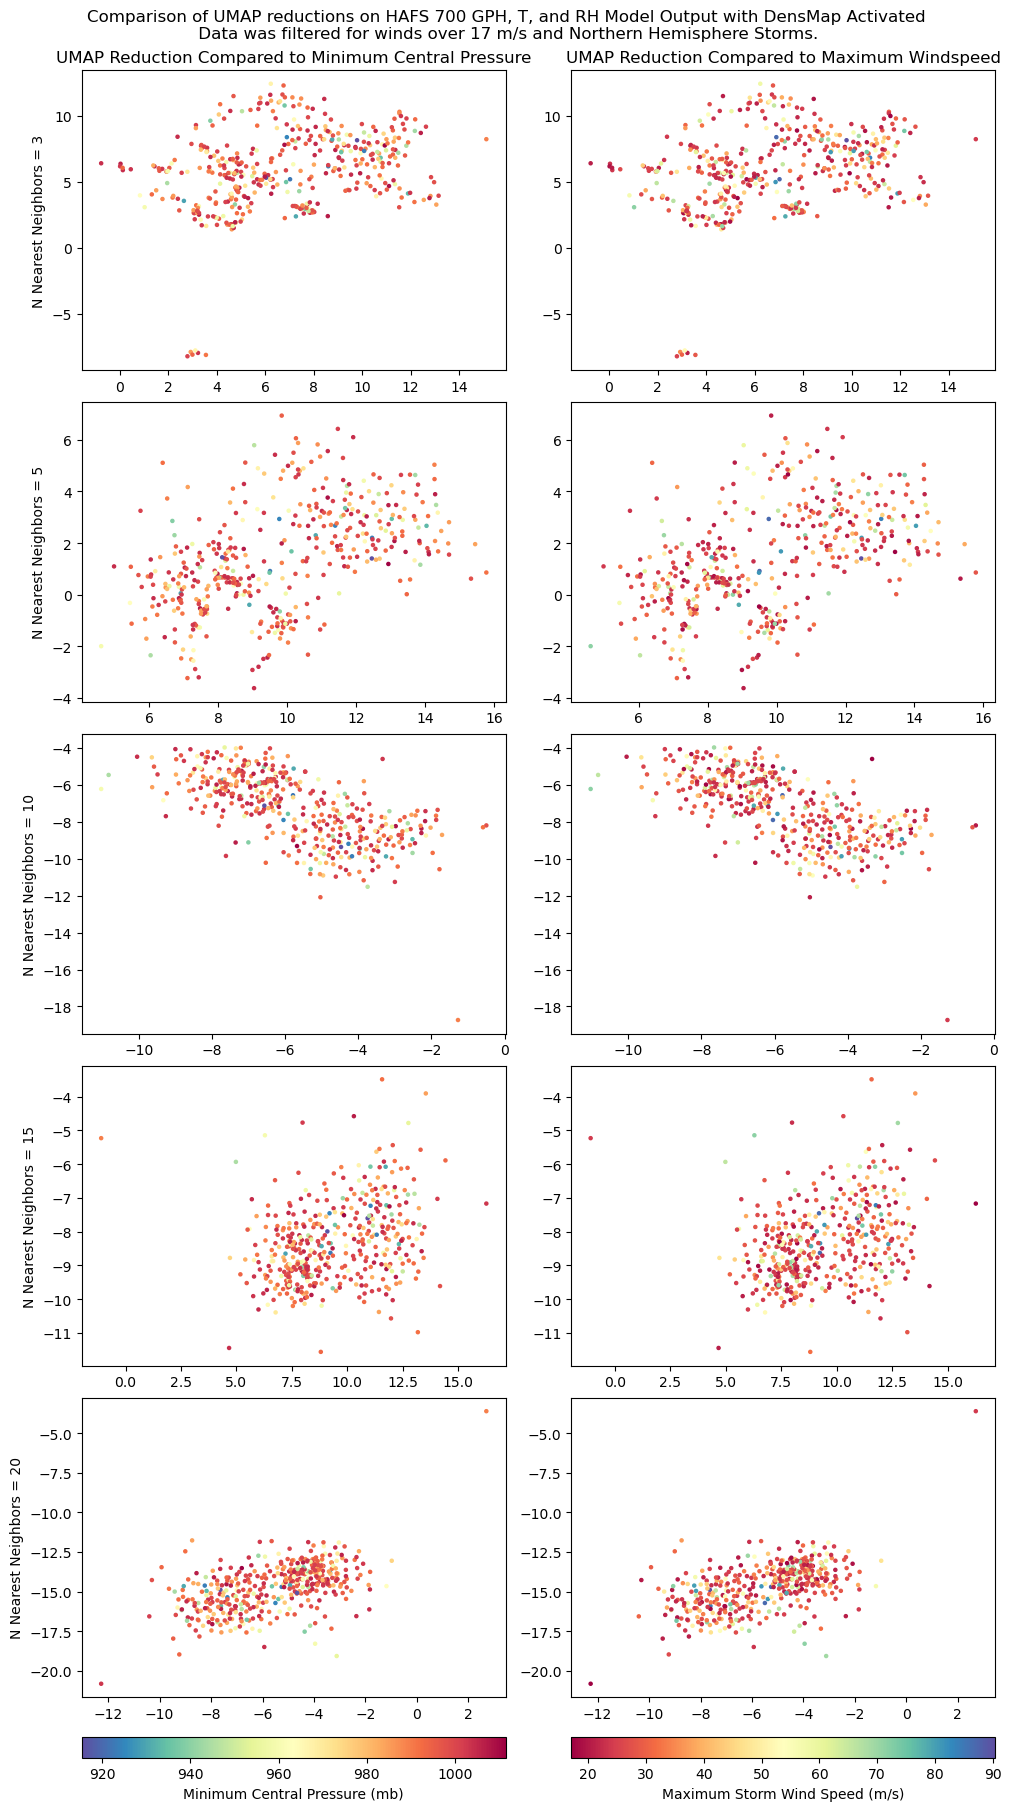

In [ ]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_GH700_n3[:,0], embedding_GH700_n3[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_GH700_n10[:,0], embedding_GH700_n10[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_GH700_n15[:,0], embedding_GH700_n15[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_GH700_n3[:,0], embedding_GH700_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_GH700_n10[:,0], embedding_GH700_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_GH700_n15[:,0], embedding_GH700_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

Plotting Composite Results

In [ ]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_composite_n3[:,0], embedding_composite_n3[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_composite_n5[:,0], embedding_composite_n5[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_composite_n10[:,0], embedding_composite_n10[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_composite_n15[:,0], embedding_composite_n15[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_composite_n20[:,0], embedding_composite_n20[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_composite_n3[:,0], embedding_composite_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_composite_n5[:,0], embedding_composite_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_composite_n10[:,0], embedding_composite_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_composite_n15[:,0], embedding_composite_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_composite_n20[:,0], embedding_composite_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of UMAP reductions on HAFS GPH at Sfc and 700 mb level, T at Sfc level Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')